In [2]:
from pathlib import Path
import librosa
import IPython.display as ipd
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd

plt.style.use("default")

# Dataset

Can be donwloaded from http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz
and should then be placed in the same folder, as this notebook.

In [3]:
DATASET_PATH = Path("speech_commands_v0.01/")
assert DATASET_PATH.exists()

OUTPUT_PATH = Path("preprocessed_dataset/")
OUTPUT_PATH.mkdir(exist_ok=True)

/home/dom/python_global_venvs/ML/venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


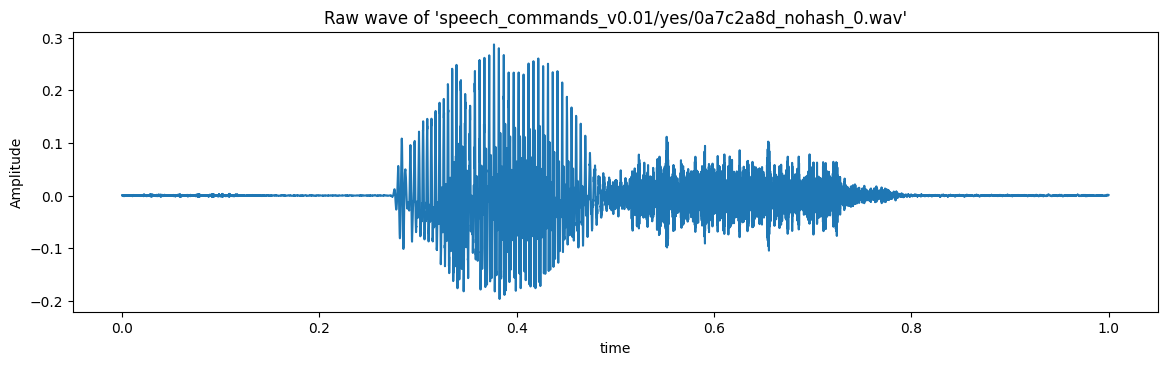

sample_rate=16000


In [4]:
audio_track_path = DATASET_PATH / "yes" / "0a7c2a8d_nohash_0.wav"
samples, sample_rate = librosa.load(audio_track_path, sr=None)
fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(211)
ax1.set_title(f"Raw wave of '{audio_track_path}'")
ax1.set_xlabel('time')
ax1.set_ylabel('Amplitude')
ax1.plot(np.linspace(0, sample_rate/len(samples), sample_rate), samples)
plt.show()

print(f"{sample_rate=}")

In [5]:
samples.min(), samples.max()

(-0.19668579, 0.28720093)

In [6]:
# Doesn't show anything in PyCharm, but one can open the notebook in Browser using triple-dot in the top-right corner
ipd.display(ipd.Audio(samples, rate=sample_rate))

In [7]:
samples = librosa.resample(np.asarray(samples, dtype=np.float32), orig_sr=sample_rate,target_sr=8000)
ipd.Audio(samples, rate=8000)

In [8]:
LABELS = np.array([
    "dog",
    "cat",
    "bird",
    "stop",
    "wow",
    "up",
    "down",
    "go",
    "happy",
    "zero",
])
len(np.unique(LABELS))

10

In [9]:
def process_file(file: Path) -> bool:
    # Reading with smaller sr automatically resamples
    samples, sample_rate = librosa.load(file, sr=8_000)
    if samples.shape[0] < 8_000:
        # Too short sample - removing from dataset
        return False

    label = file.parents[0].name
    output_file_path = OUTPUT_PATH / label / file.name
    sf.write(output_file_path, samples, sample_rate)
    return True

In [10]:
y_counts = np.zeros_like(LABELS, dtype=int)

for i, label in tqdm(enumerate(LABELS)):
    output_folder = OUTPUT_PATH / label
    output_folder.mkdir(parents=True, exist_ok=True)

    files_count = 0
    folder_path = DATASET_PATH / label
    for file in folder_path.iterdir():
        files_count += int(process_file(file))

    y_counts[i] = files_count

0it [00:06, ?it/s]


KeyboardInterrupt: 

In [ ]:
plt.bar(LABELS, y_counts)

In [ ]:
df = pd.DataFrame(np.concatenate((LABELS.reshape(-1, 1), y_counts.reshape(-1, 1)), axis=1), columns=["label", "num_samples"])
df.to_csv("preprocessed_dataset/labels_num_samples.csv", index=False)
df